## Exercise V: MNIST GAN - Learn to generate MNIST digits [25 Marks]
The goal of this exercise is to learn to generate MNIST digits, which are $28 \times 28$ grayscale images of the $10$ digits. The exercise will be partially guided. Please comment on your reasoning when writing the code.

* So we are generating MNIST digits - 28x28 dimensions - there are 10 digits - 0-9


In [2]:
# Import the necessary libraries
from keras.datasets import mnist
from keras.models import Sequential, Model
from keras.layers import Input, Dense, Dropout, Activation, Flatten, BatchNormalization, Conv2D, Conv2DTranspose, Reshape
from keras.layers import LeakyReLU
from keras.optimizers import Adam, RMSprop
import numpy as np
import matplotlib.pyplot as plt
import random
import keras
from tqdm import tqdm_notebook
seed = 2026

random.seed(seed)
np.random.seed(seed)

# Import the dataset of 60,000 28x28 grayscale images of the 10 digits, along with a test set of 10,000 images.
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

The following code rescales data since we are using ReLU activations.

In [3]:
# Import the dataset of 60,000 28x28 grayscale images of the 10 digits,
# along with a test set of 10,000 images.
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()


### I have uncommented this because i want to use CNN to exploit the spacial information, which we remove by flattening
# So we load in the MNIST dataset - here we reshape the images which are 28x28
# Then we flatten to a 1D vector of dimensional length 784
# X_train = X_train.reshape(60000, 784)
# X_test  = X_test.reshape(10000, 784)

# Pixel values are rescaled from 0-255 to 0,1 by dividing
# We rescale because
X_train = X_train.astype('float32')/255
X_test  = X_test.astype('float32')/255

img_dimension = X_train.shape[1:] # Should be 784, it is now 28*28, because we do not flatten
img_dimension

(28, 28)

In [4]:
# Helper Functions
def sample_noise(n_samples, z_dim):
  """
  Here we are drawing noise vectors from a standard normal distribution
  """
  return np.random.normal(0, 1, size=(n_samples, z_dim))

def sample_real_images(X, n_samples, smooth_real_labels=True):
  """
  Sampling a mini-batch of real images from the provided traing set
  The smooth real images parameter is used for stability
  """

  id = np.random.randint(0, X.shape[0], n_samples)
  x_real = X[id]

  y_real = np.ones((n_samples, 1))
  #if smooth_real_labels:
  #  y_real *= 0.9

  return x_real, y_real

def sample_fake_images(generator, z_dim, n_samples):
  """
  Generate a mini-batch of fake images which get assigned a corresponding 0 label
  """
  noise = sample_noise(n_samples, z_dim)
  x_fake = generator.predict(noise, verbose=0)
  y_fake = np.zeros((n_samples, 1), dtype=np.float32)
  return x_fake, y_fake


**Activation** <br>

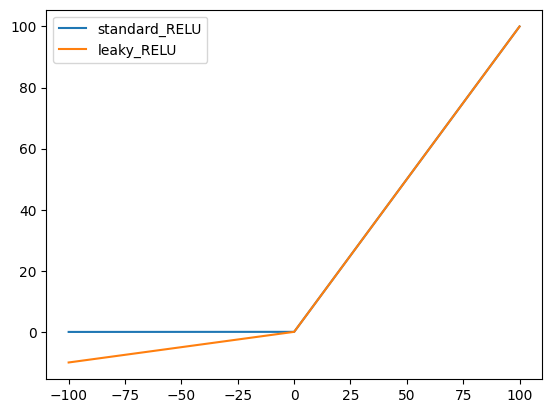

In [5]:
def leakyReLU(x,neg_scale=0.01):
  if x > 0:
    return x
  else:
    return neg_scale*x

std_relu = []
leaky_relu = []

std_relu = [leakyReLU(x,neg_scale=0) for x in np.linspace(-100,100,10000)]
leaky_relu = [leakyReLU(x,neg_scale=0.1) for x in np.linspace(-100,100,10000)]

plt.plot(np.linspace(-100,100,10000),std_relu, label='standard_RELU')
plt.plot(np.linspace(-100,100,10000),leaky_relu, label='leaky_RELU')
plt.legend()
plt.show()

Below we define functions to build our models. Modularising the model build into functions works best with keras's model building architecture and model storage (The functions here are repurposed from the lecture notebooks - adjusting the model architecture for the purpose of this excercise).


In [6]:
## De
def build_generator(z_dim, dropout_rate=0.30, lr=0.0002):
  g = Sequential()
  g.add(Input(shape=(z_dim,)))
  g.add(Dense(6272)) # 6272=7*7*128
  g.add(LeakyReLU(0.2))
  g.add(Reshape((7, 7, 128)))
  g.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
  g.add(LeakyReLU(0.2))
  g.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
  g.add(LeakyReLU(0.2))
  g.add(Conv2D(1, (7,7), activation='sigmoid', padding='same'))

  return g

def build_discriminator(in_shape=(28,28,1), dropout_rate=0.30, lr=0.00005):
  d = Sequential()
  d.add(Input(shape=in_shape))
  d.add(Conv2D(64, (3,3), strides=(2, 2), padding='same'))
  d.add(LeakyReLU(0.2))
  d.add(Dropout(dropout_rate))
  d.add(Conv2D(64, (3,3), strides=(2, 2), padding='same'))
  d.add(LeakyReLU(0.2))
  d.add(Dropout(dropout_rate))
  d.add(Dense(256, kernel_initializer=keras.initializers.HeNormal()))
  d.add(LeakyReLU(0.2))
  d.add(Dropout(dropout_rate))
  d.add(Flatten())

  d.add(Dense(1, activation="sigmoid"))

  d.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=lr), metrics=['accuracy'])
  return d

def build_gan(generator, discriminator, z_dim=100, lr=0.0002):
  """
  We use the built GAN to train the generator, with the discriminator remaining static/frozen within the model
  """
  discriminator.trainable=False # Renabling the discriminator to allow for standalone discriminator training

  gan_input = Input(shape=(z_dim,))
  fake_img = generator(gan_input)
  gan_output = discriminator(fake_img)

  gan = Model(gan_input, gan_output)

  gan.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate=lr, beta_1=0.5), metrics=['accuracy'])
  return gan

In [7]:
def plot_generated(generator, z_dim, n_ex=10, dim=(1, 10), figsize=(12, 2), title=None):
    """
    Plots a grid of our generated images
    """
    noise = sample_noise(n_ex, z_dim)
    generated_images = generator.predict(noise, verbose=0)
    generated_images = generated_images.reshape(n_ex, 28, 28)

    plt.figure(figsize=figsize)
    for i in range(n_ex):
        plt.subplot(dim[0], dim[1], i + 1)
        plt.imshow(generated_images[i], cmap="gray")
        plt.axis("off")

    if title is not None:
        plt.suptitle(title, y=1.02)

    plt.tight_layout()
    plt.show()


def plot_loss(history):
    """
    Plotting the accuracy for discriminator and loss for both discriminator and generator
    """
    epochs = np.arange(1, len(history["d_loss"]) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history["d_loss"], label="Discriminator loss")
    plt.plot(epochs, history["g_loss"], label="Generator loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("GAN losses over training")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history["d_acc"], label="Discriminator accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Discriminator accuracy over training")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:
def train_mnist_gan(X, z_dim=100,epochs=40, batch_size=128, sample_interval=5, smooth_real_labels=True, g_lr=0.0002, d_lr=0.0002, verbose=True):
    """
    This function calls our training procedure for the GAN model

    """
    # step 1, build discriminator and compile
    discriminator = build_discriminator( lr=d_lr)

    # step 2
    generator = build_generator(z_dim=z_dim, lr=g_lr)

    gan = build_gan(generator, discriminator, lr=g_lr)

    history = {"d_loss": [], "d_acc": [], "g_loss": []}

    half_batch = int(batch_size/2)
    batches_per_epoch = X.shape[0] // batch_size

    for epoch in range(1, epochs + 1):
        epoch_d_losses, epoch_d_accs, epoch_g_losses = [], [], []

        for _ in range(batches_per_epoch): # Here we train our discriminator model
            x_real, y_real = sample_real_images(X, half_batch, smooth_real_labels=smooth_real_labels) # real images sampled from our dataset via our mini-batch assembly function
            x_fake, y_fake = sample_fake_images(generator, z_dim, half_batch) #fake images produced by our generator model with the specified parameters

            discriminator.trainable = True
            d_real = discriminator.train_on_batch(x_real, y_real) # d_real is the return value of the training procedure - i.e. our loss and accuracy when completing training on the real labelled images
            d_fake = discriminator.train_on_batch(x_fake, y_fake) # # d_real is the return value of the training procedure - i.e. our loss and accuracy when completing training on the fake generated images

            d_loss = 0.5 * (float(d_real[0]) + float(d_fake[0])) #our discriminator loss we can depitct as the average of the losses across the real and fake image classifications
            d_acc  = 0.5 * (float(d_real[1]) + float(d_fake[1])) # same as above for our accuracy

            discriminator.trainable = False
            # the discriminator was outperforming the generator, so to give it an advantage, we do it twice
            for _ in range(2):
              # generating our noise
              noise = sample_noise(batch_size, z_dim)
              # Generator wants discriminator to believe fake images are real
              misleading_targets = np.ones((batch_size, 1), dtype=np.float32)
              g_loss = gan.train_on_batch(noise, misleading_targets, return_dict=False)
            #print(g_loss[0], "*****")
            g_loss = float(g_loss[0])

            epoch_d_losses.append(d_loss)
            epoch_d_accs.append(d_acc)
            epoch_g_losses.append(g_loss)

        # Store epoch averages
        history["d_loss"].append(np.mean(epoch_d_losses))
        history["d_acc"].append(np.mean(epoch_d_accs))
        history["g_loss"].append(np.mean(epoch_g_losses))

        if verbose:
            print(f"Epoch {epoch:03d}/{epochs} | \n D loss: {history['d_loss'][-1]:.4f} | \n D acc: {history['d_acc'][-1]:.4f} | \n G loss: {history['g_loss'][-1]:.4f}")

        # At intervals we can inspect the digits produced to get a visual understanding of the generator activity/mechanism over time
        if sample_interval is not None:
            if (epoch == 1) or (epoch % sample_interval == 0) or (epoch == epochs):
                plot_generated(generator, z_dim, n_ex=10, dim=(1, 10), figsize=(12, 2), title=f"Generated digits after epoch {epoch}")

    return generator, discriminator, gan, history

**To fill with analysis**

Epoch 001/40 | 
 D loss: 0.6083 | 
 D acc: 0.7402 | 
 G loss: 1.2429


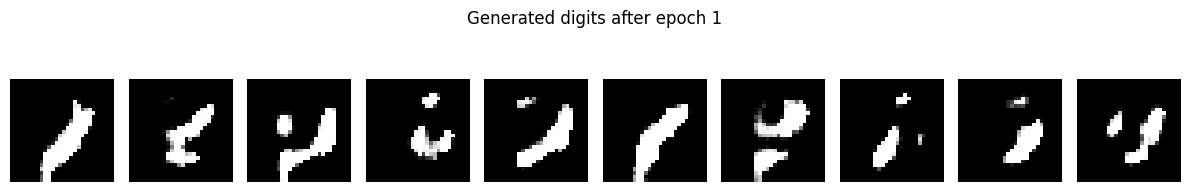

Epoch 002/40 | 
 D loss: 0.6985 | 
 D acc: 0.5651 | 
 G loss: 0.9419
Epoch 003/40 | 
 D loss: 0.7007 | 
 D acc: 0.5276 | 
 G loss: 0.8415
Epoch 004/40 | 
 D loss: 0.6997 | 
 D acc: 0.5163 | 
 G loss: 0.7994
Epoch 005/40 | 
 D loss: 0.6990 | 
 D acc: 0.5087 | 
 G loss: 0.7761


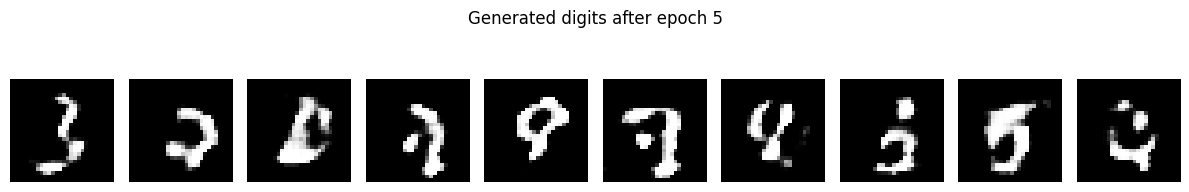

Epoch 006/40 | 
 D loss: 0.6980 | 
 D acc: 0.5069 | 
 G loss: 0.7612
Epoch 007/40 | 
 D loss: 0.6971 | 
 D acc: 0.5093 | 
 G loss: 0.7512
Epoch 008/40 | 
 D loss: 0.6965 | 
 D acc: 0.5097 | 
 G loss: 0.7439
Epoch 009/40 | 
 D loss: 0.6963 | 
 D acc: 0.5079 | 
 G loss: 0.7382
Epoch 010/40 | 
 D loss: 0.6961 | 
 D acc: 0.5061 | 
 G loss: 0.7338


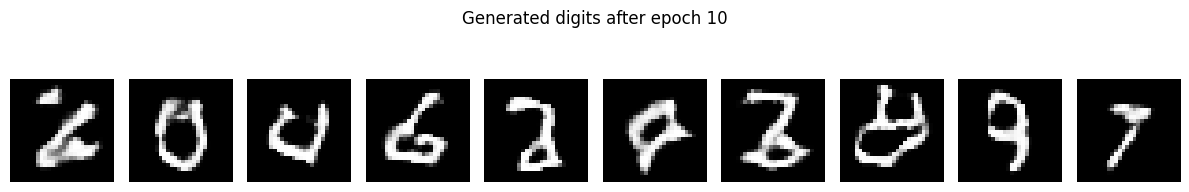

Epoch 011/40 | 
 D loss: 0.6959 | 
 D acc: 0.5052 | 
 G loss: 0.7301
Epoch 012/40 | 
 D loss: 0.6957 | 
 D acc: 0.5045 | 
 G loss: 0.7271
Epoch 013/40 | 
 D loss: 0.6955 | 
 D acc: 0.5043 | 
 G loss: 0.7245
Epoch 014/40 | 
 D loss: 0.6953 | 
 D acc: 0.5041 | 
 G loss: 0.7223
Epoch 015/40 | 
 D loss: 0.6952 | 
 D acc: 0.5041 | 
 G loss: 0.7204


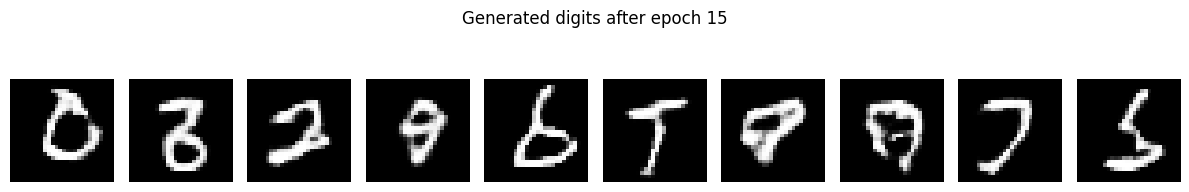

Epoch 016/40 | 
 D loss: 0.6951 | 
 D acc: 0.5041 | 
 G loss: 0.7188
Epoch 017/40 | 
 D loss: 0.6950 | 
 D acc: 0.5040 | 
 G loss: 0.7174
Epoch 018/40 | 
 D loss: 0.6949 | 
 D acc: 0.5041 | 
 G loss: 0.7161
Epoch 019/40 | 
 D loss: 0.6948 | 
 D acc: 0.5042 | 
 G loss: 0.7150
Epoch 020/40 | 
 D loss: 0.6947 | 
 D acc: 0.5044 | 
 G loss: 0.7140


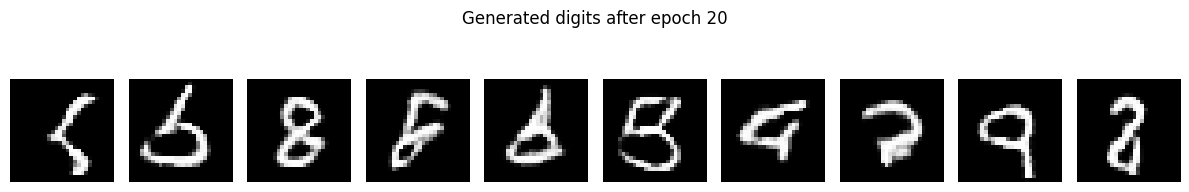

Epoch 021/40 | 
 D loss: 0.6946 | 
 D acc: 0.5046 | 
 G loss: 0.7131
Epoch 022/40 | 
 D loss: 0.6945 | 
 D acc: 0.5047 | 
 G loss: 0.7122
Epoch 023/40 | 
 D loss: 0.6945 | 
 D acc: 0.5047 | 
 G loss: 0.7115
Epoch 024/40 | 
 D loss: 0.6944 | 
 D acc: 0.5047 | 
 G loss: 0.7108
Epoch 025/40 | 
 D loss: 0.6944 | 
 D acc: 0.5047 | 
 G loss: 0.7102


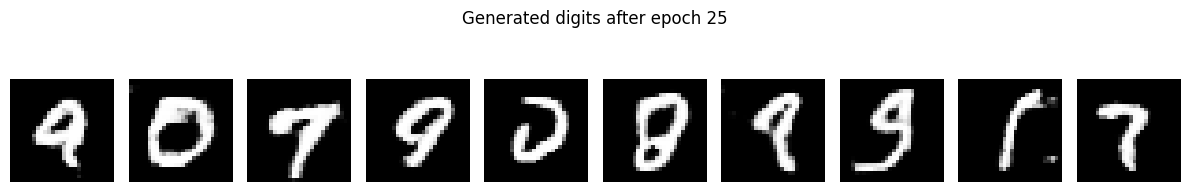

Epoch 026/40 | 
 D loss: 0.6943 | 
 D acc: 0.5047 | 
 G loss: 0.7096
Epoch 027/40 | 
 D loss: 0.6943 | 
 D acc: 0.5048 | 
 G loss: 0.7090
Epoch 028/40 | 
 D loss: 0.6942 | 
 D acc: 0.5048 | 
 G loss: 0.7085
Epoch 029/40 | 
 D loss: 0.6942 | 
 D acc: 0.5048 | 
 G loss: 0.7081
Epoch 030/40 | 
 D loss: 0.6942 | 
 D acc: 0.5049 | 
 G loss: 0.7076


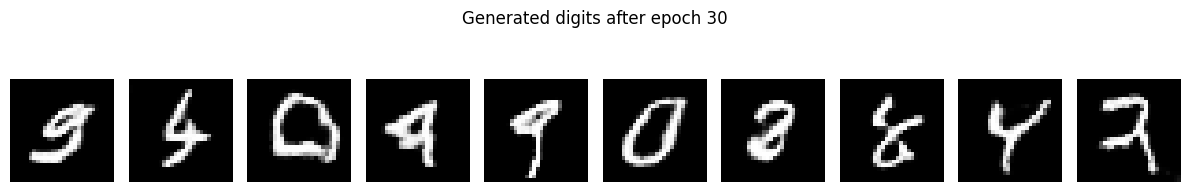

Epoch 031/40 | 
 D loss: 0.6941 | 
 D acc: 0.5049 | 
 G loss: 0.7072
Epoch 032/40 | 
 D loss: 0.6941 | 
 D acc: 0.5049 | 
 G loss: 0.7068
Epoch 033/40 | 
 D loss: 0.6941 | 
 D acc: 0.5050 | 
 G loss: 0.7065
Epoch 034/40 | 
 D loss: 0.6940 | 
 D acc: 0.5050 | 
 G loss: 0.7062
Epoch 035/40 | 
 D loss: 0.6940 | 
 D acc: 0.5051 | 
 G loss: 0.7058


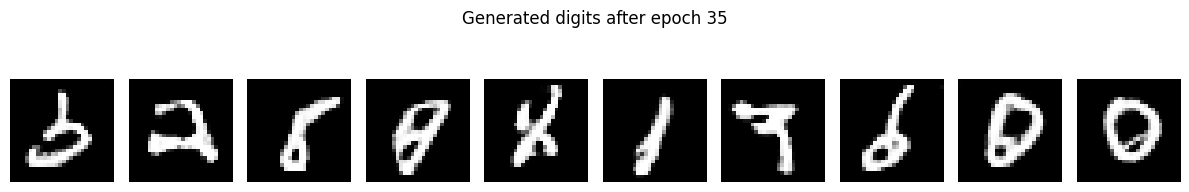

Epoch 036/40 | 
 D loss: 0.6940 | 
 D acc: 0.5051 | 
 G loss: 0.7055
Epoch 037/40 | 
 D loss: 0.6940 | 
 D acc: 0.5051 | 
 G loss: 0.7053
Epoch 038/40 | 
 D loss: 0.6940 | 
 D acc: 0.5051 | 
 G loss: 0.7050
Epoch 039/40 | 
 D loss: 0.6939 | 
 D acc: 0.5051 | 
 G loss: 0.7048
Epoch 040/40 | 
 D loss: 0.6939 | 
 D acc: 0.5050 | 
 G loss: 0.7045


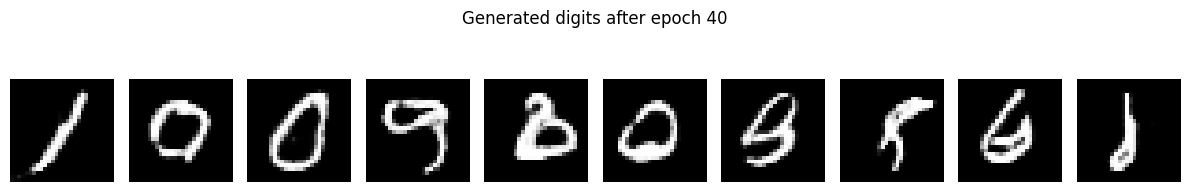

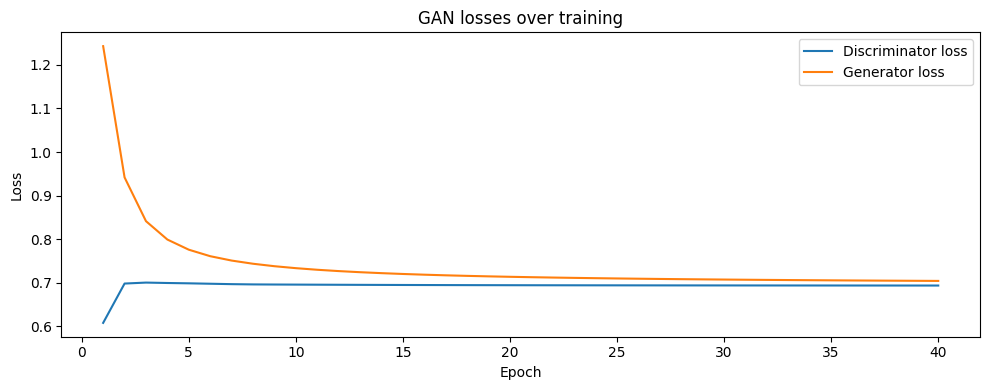

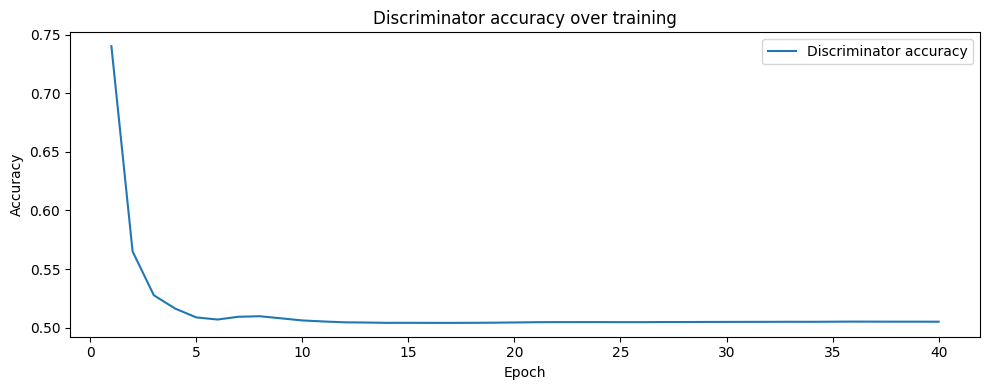

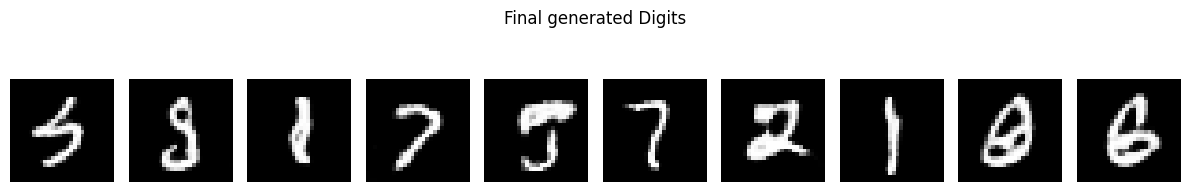

In [9]:
# start by using z_dim as 100 as prescribed by the course guidelines
z_dim =100
generator, discriminator, gan, history = train_mnist_gan(X_train, z_dim=z_dim, epochs=40, batch_size=128, sample_interval=5, smooth_real_labels=True, verbose=True)
plot_loss(history)
plot_generated(generator, z_dim, n_ex=10, dim=(1,10), figsize=(12,2), title="Final generated Digits")

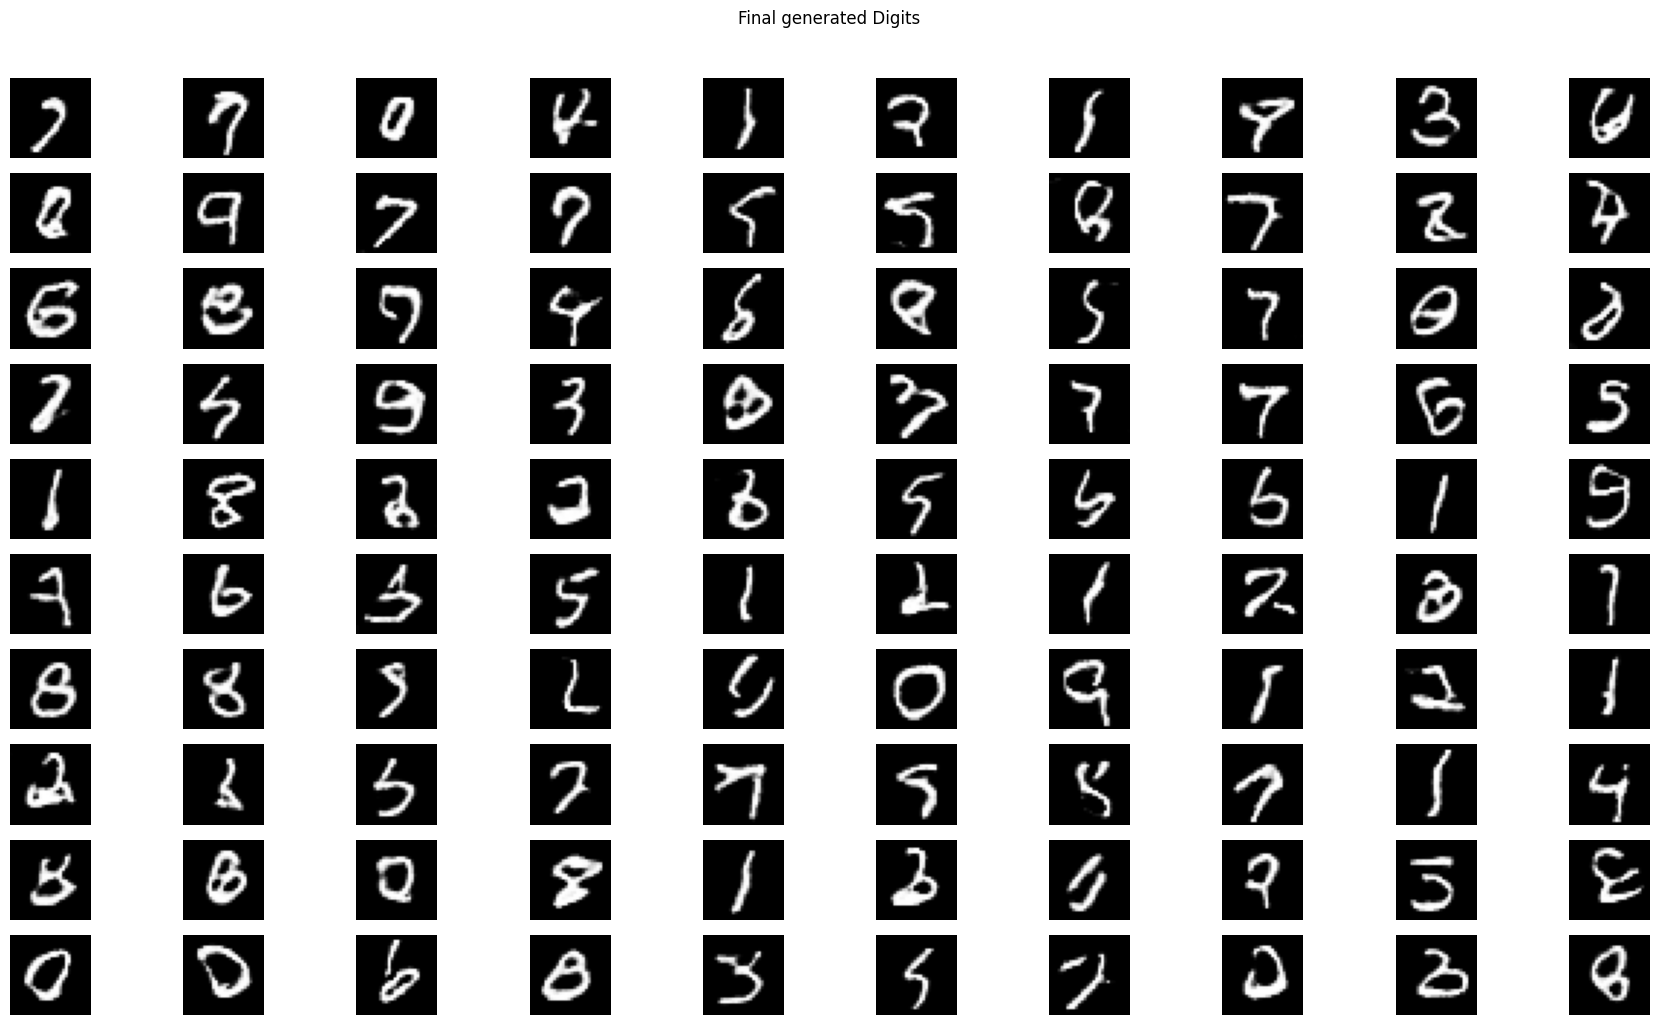

In [19]:
plot_generated(generator, z_dim, n_ex=100, dim=(10,10), figsize=(18,10), title="Final generated Digits")

In [10]:
# I haven't adjusted this one for the updates
def compare_different_dimensions(X, z_dims=(25,50,100,150,200), epochs_per_run=10, batch_size=128, tail_average=3):
    """
    This function allows us to compare the different latent dimensions, as specified in the brief.
    The function records averaged losses for the discriminator and generator as well as discriminator accuracy across each z_dim passed into the function call
    """
    results = {"z_dim": [], "d_loss": [], "d_acc": [], "g_loss": []}

    trained_generators = {}

    for z in z_dims:
        print(f"Beginnging run for z_dim = {z}")
        g, d, gan_model, h = train_mnist_gan(X,  z_dim=z, epochs=epochs_per_run, batch_size=batch_size, sample_interval=None, smooth_real_labels=True, verbose=False)
        tail = min(tail_average, len(h["g_loss"]))

        results["z_dim"].append(z)
        results["d_loss"].append(np.mean(h["d_loss"][-tail:]))
        results["d_acc"].append(np.mean(h["d_acc"][-tail:]))
        results["g_loss"].append(np.mean(h["g_loss"][-tail:]))

        trained_generators[z] = g

    # Plot final smoothed losses against the particular dimensions for our z noise
    plt.figure(figsize=(10, 4))
    plt.plot(results["z_dim"], results["d_loss"], marker="o", label="Discriminator loss")
    plt.plot(results["z_dim"], results["g_loss"], marker="o", label="Generator loss")
    plt.xlabel("Latent dimension (z_dim)")
    plt.ylabel("Final averaged loss")
    plt.title("Performance diagnostics vs latent dimension")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot final discriminator accuracy against the particular dimensions for our z noise
    plt.figure(figsize=(10, 4))
    plt.plot(results["z_dim"], results["d_acc"], marker="o", label="Discriminator accuracy")
    plt.xlabel("Latent dimension (z_dim)")
    plt.ylabel("Final averaged accuracy")
    plt.title("Discriminator accuracy vs latent dimension")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Show a small generated sample for each latent dimension
    for z in z_dims:
        plot_generated(trained_generators[z], z, n_ex=10, dim=(1, 10), figsize=(12, 2), title=f"Generated digits for z_dim = {z}")

    return results, trained_generators



results, generators = compare_different_dimensions(X_train, z_dims=(25, 50, 100, 150, 200), epochs_per_run=10, batch_size=128)


Beginnging run for z_dim = 25


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'input_layer_4' of layer 'functional_38' is incompatible with the layer: expected shape=(None, 25), found shape=(None, 100)[0m

Arguments received by Sequential.call():
  • args=('<KerasTensor shape=(None, 100), dtype=float32, sparse=False, ragged=False, name=keras_tensor_211>',)
  • kwargs={'mask': 'None'}

**To fill with analysis**

## Individual technical contributions [5 Marks]

Your individual report is a chance to apply critical thought to the process and lessons learned from the Coursework I. This part should contain a summary of your individual technical contributions to the project, and an appreciation of what you think you could have done better, an identification of the areas for further personal development.



1.   CANDIDATE NUMBER 1: ....
2.   CANDIDATE NUMBER 2: ....

